In [166]:
!pip install python-dotenv


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
from dotenv import load_dotenv  # подключаем .env файл с секретами
import requests  # делаем HTTP-запросы
import os  # читаем переменные окружения
import json

load_dotenv()  # загружаем переменные из .env
CLIENT_ID = 54386297  # получаем CLIENT_ID из .env

# формируем ссылку для получения access_token через OAuth
url = f"https://oauth.vk.com/authorize?client_id={CLIENT_ID}&redirect_uri=https://oauth.vk.com/blank.html&response_type=token&scope=8194"

response = requests.get(url, allow_redirects=True)  # отправляем запрос и следуем редиректам
print(response.url)  # выводим финальный URL, где в адресной строке будет access_token

https://oauth.vk.com/authorize?client_id=54386297&redirect_uri=https://oauth.vk.com/blank.html&response_type=token&scope=8194


In [84]:
access_token = "vk1.a.ks6Mf8fNA9EHPjxZmyE3uMGDCdl-BauJdwrx9WL6zXw5o7ueafvvTYCEuG5pXpJMUXZ2mkNfuZImzAcLXUsQyRmub7YM4xTEGV4nhJCjOaeMnoG_9-YIEJ07HSxnR_4Nqz-Gw377JnteUCKoAsEdhU7alCupb0ArCeNoOgFhBcyyzOiKLA19xmFslB2BD1FccmzCAKJnfkuL3AxQc-WUvQ"

In [86]:
# Константы (лучше вынести в конфиг или .env)
VK_API_BASE = "https://api.vk.ru/method/"
API_VERSION = "5.131"


def make_vk_request(method, params=None):
    """
    Отправляет GET-запрос к API ВКонтакте.

    :param method: Название метода API (например, 'users.get')
    :param params: Словарь с параметрами запроса (без v и access_token — они добавятся автоматически)
    :return: Ответ API в формате JSON или None при ошибке
    """
    url = f"{VK_API_BASE}{method}"
    # Создаём копию параметров, чтобы не изменять исходный словарь
    request_params = (params or {}).copy()
    # Автоматически добавляем обязательные параметры
    request_params["v"] = API_VERSION
    request_params["access_token"] = access_token

    response = requests.get(url, params=request_params)

    if response.status_code == 200:
        return response.json()
    else:
        print("Ошибка при выполнении запроса:", response.status_code, response.text)
        return None

In [87]:
params = {
    "user_ids": "a.kryukov0",
    "name_case": "nom"
}

data = make_vk_request("users.get", params)

if data:
    print("Ответ:", data)
    if "response" in data:
        result_array = data["response"]
        central_user_id = result_array[0]['id']
        print(f"id пользователя для запроса списка друзей {central_user_id}")
    else:
        print("Ключ 'response' отсутствует в ответе:", data)

Ответ: {'response': [{'id': 253997298, 'first_name': 'Александр', 'last_name': 'Крюков', 'can_access_closed': True, 'is_closed': False}]}
id пользователя для запроса списка друзей 253997298


In [88]:
import requests
import time

CITY_CACHE = {}

def add_city_coords(friend):
    """
    Добавляет в объект друга поля:
      city_lat, city_lon
    используя Nominatim (OpenStreetMap).
    """
    if "city" not in friend or "title" not in friend["city"]:
        return friend  # города нет → нечего добавлять

    city_name = friend["city"]["title"]

    # если уже искали — берём из кеша
    if city_name in CITY_CACHE:
        friend["city_lat"], friend["city_lon"] = CITY_CACHE[city_name]
        return friend

    try:
        url = "https://nominatim.openstreetmap.org/search"
        params = {
            "q": city_name,
            "format": "json",
            "limit": 1
        }
        headers = {"User-Agent": "VK-Student-Project/1.0"}

        r = requests.get(url, params=params, headers=headers)
        data = r.json()

        if data:
            lat = float(data[0]["lat"])
            lon = float(data[0]["lon"])
        else:
            lat, lon = None, None

        CITY_CACHE[city_name] = (lat, lon)

        friend["city_lat"] = lat
        friend["city_lon"] = lon

        time.sleep(1)  # Nominatim ограничивает 1 запрос в секунду

    except Exception as e:
        print(f"[Геокодер ошибка] {city_name}: {e}")
        friend["city_lat"] = None
        friend["city_lon"] = None

    return friend

In [89]:
# Ограничения (API VK имеет лимиты)
MAX_DEPTH = 2
MAX_FRIENDS_PER_USER = 50  # Ограничим для скорости и лимитов
REQUEST_DELAY = 0.35  # Задержка между запросами (в сек), чтобы не превысить лимиты

def get_friends(user_id, fields=None):
    """
    Возвращает список друзей одного пользователя (один уровень).
    Параллельно сохраняет полный ответ friends.get в friends_<id>.json.
    Добавляет lat/lon города через Nominatim.
    """
    try:
        params = {
            "user_id": user_id,
            "count": MAX_FRIENDS_PER_USER
        }
        if fields:
            params["fields"] = fields

        response = make_vk_request("friends.get", params)

        if not response or "error" in response or "response" not in response:
            print(f"[Ошибка VK] user_id={user_id}")
            return []

        payload = response["response"]
        items = payload.get("items", [])

        # --- ДОБАВЛЯЕМ КООРДИНАТЫ ГОРОДА К КАЖДОМУ ДРУГУ ---
        for fr in items:
            add_city_coords(fr)

        # сохраняем json уже с координатами
        filename = f"friends/friends_{user_id}.json"
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(payload, f, ensure_ascii=False, indent=4)

        print(f"Файл сохранён: {filename}")

        return items

    except Exception as e:
        print(f"[Исключение] get_friends({user_id}) -> {e}")
        return []


In [91]:
# Тестируем получение друзей
get_friends(central_user_id, "city,sex,bdate")

Файл сохранён: friends/friends_253997298.json


[{'id': 109210,
  'bdate': '23.7.1989',
  'city': {'id': 109, 'title': 'Пенза'},
  'track_code': 'b712772bB_3iN0quByorE_8Z_hT8HvJMYHcjj1dgeSP0v4IHy2Vqlu8GfKgFdigUz9Au2yJ2hVgSHkbh',
  'sex': 1,
  'first_name': 'Инга',
  'last_name': 'Нарбекова',
  'can_access_closed': True,
  'is_closed': False,
  'city_lat': 53.1937836,
  'city_lon': 45.0067413},
 {'id': 5501334,
  'bdate': '10.5',
  'city': {'id': 109, 'title': 'Пенза'},
  'track_code': '23d01edekjN3RnU--zEOP-Tc6TGeqYXaQ0pWQgtDDcbtsMOo9bL_WHp3QTmoNw471idS8lPY_NlDIzMsbw',
  'sex': 1,
  'first_name': 'Татьяна',
  'last_name': 'Белоусова',
  'can_access_closed': True,
  'is_closed': False,
  'city_lat': 53.1937836,
  'city_lon': 45.0067413},
 {'id': 6025948,
  'city': {'id': 109, 'title': 'Пенза'},
  'track_code': '78da6644vAPTKAwZTAYkpG-9WyglfrzDPaCcQm76tAuvsKLsF3nRaIwdOhtPUiipWUrg6-gPxcA9yfksCg',
  'sex': 1,
  'first_name': 'Мария',
  'last_name': 'Савинкина',
  'can_access_closed': True,
  'is_closed': False,
  'city_lat': 53.1937836,

In [92]:
import json
import csv
from collections import deque
from time import sleep


def build_friends_graph(root_id, fields=None, max_depth=MAX_DEPTH):
    visited = set()
    queue = deque([(root_id, 0)])

    graph_rows = []   # сюда собираем строки для одного CSV
    users_cache = {}  # кеш информации о пользователях

    while queue:
        uid, depth = queue.popleft()
        if depth >= max_depth or uid in visited:
            continue
        visited.add(uid)

        friends = get_friends(uid, fields=fields)

        # инфа о самом пользователе (from_*)
        if uid not in users_cache:
            users_cache[uid] = {}
        from_info = users_cache.get(uid, {})

        from_sex = from_info.get("sex")
        from_city_obj = from_info.get("city") if isinstance(from_info.get("city"), dict) else {}
        from_city = from_city_obj.get("title")
        from_city_lat = from_city_obj.get("lat")
        from_city_lon = from_city_obj.get("lon")
        from_first = from_info.get("first_name")
        from_last = from_info.get("last_name")

        for friend in friends:
            fid = friend["id"]

            # кладём инфу о друге в кеш
            users_cache[fid] = friend

            to_sex = friend.get("sex")
            to_city_obj = friend.get("city") if isinstance(friend.get("city"), dict) else {}
            to_city = to_city_obj.get("title")
            to_city_lat = to_city_obj.get("lat")
            to_city_lon = to_city_obj.get("lon")
            to_first = friend.get("first_name")
            to_last = friend.get("last_name")

            graph_rows.append({
                "from_id": uid,
                "to_id": fid,
                "from_sex": from_sex,
                "to_sex": to_sex,
                "from_city": from_city,
                "to_city": to_city,
                "from_city_lat": from_city_lat,
                "from_city_lon": from_city_lon,
                "to_city_lat": to_city_lat,
                "to_city_lon": to_city_lon,
                "from_first_name": from_first,
                "from_last_name": from_last,
                "to_first_name": to_first,
                "to_last_name": to_last,
            })

            if depth + 1 < max_depth:
                queue.append((fid, depth + 1))

        sleep(REQUEST_DELAY)

    # сохраняем ОДИН CSV
    csv_name = f"friends_graph_{root_id}.csv"
    fieldnames = [
        "from_id", "to_id",
        "from_sex", "to_sex",
        "from_city", "to_city",
        "from_city_lat", "from_city_lon",
        "to_city_lat", "to_city_lon",
        "from_first_name", "from_last_name",
        "to_first_name", "to_last_name",
    ]
    with open(csv_name, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(graph_rows)

    print(f"Граф сохранён в CSV: {csv_name}")
    return graph_rows

In [93]:
graph_rows = build_friends_graph(
    root_id=central_user_id,
    fields="city,sex,bdate",
    max_depth=MAX_DEPTH
)


Файл сохранён: friends/friends_253997298.json
Файл сохранён: friends/friends_109210.json
Файл сохранён: friends/friends_5501334.json
Файл сохранён: friends/friends_6025948.json
[Ошибка VK] user_id=6098838
Файл сохранён: friends/friends_7112155.json
Файл сохранён: friends/friends_7492381.json
Файл сохранён: friends/friends_10379486.json
Файл сохранён: friends/friends_12533719.json
Файл сохранён: friends/friends_16562531.json
Файл сохранён: friends/friends_17107945.json
Файл сохранён: friends/friends_18559160.json
Файл сохранён: friends/friends_24983632.json
Файл сохранён: friends/friends_67747171.json
Файл сохранён: friends/friends_71120919.json
Файл сохранён: friends/friends_82647486.json
[Ошибка VK] user_id=94038568
Файл сохранён: friends/friends_102611347.json
Файл сохранён: friends/friends_107913662.json
Файл сохранён: friends/friends_114429569.json
[Ошибка VK] user_id=115132510
Файл сохранён: friends/friends_126197267.json
[Ошибка VK] user_id=133009875
Файл сохранён: friends/friend

In [191]:
!pip install networkx matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


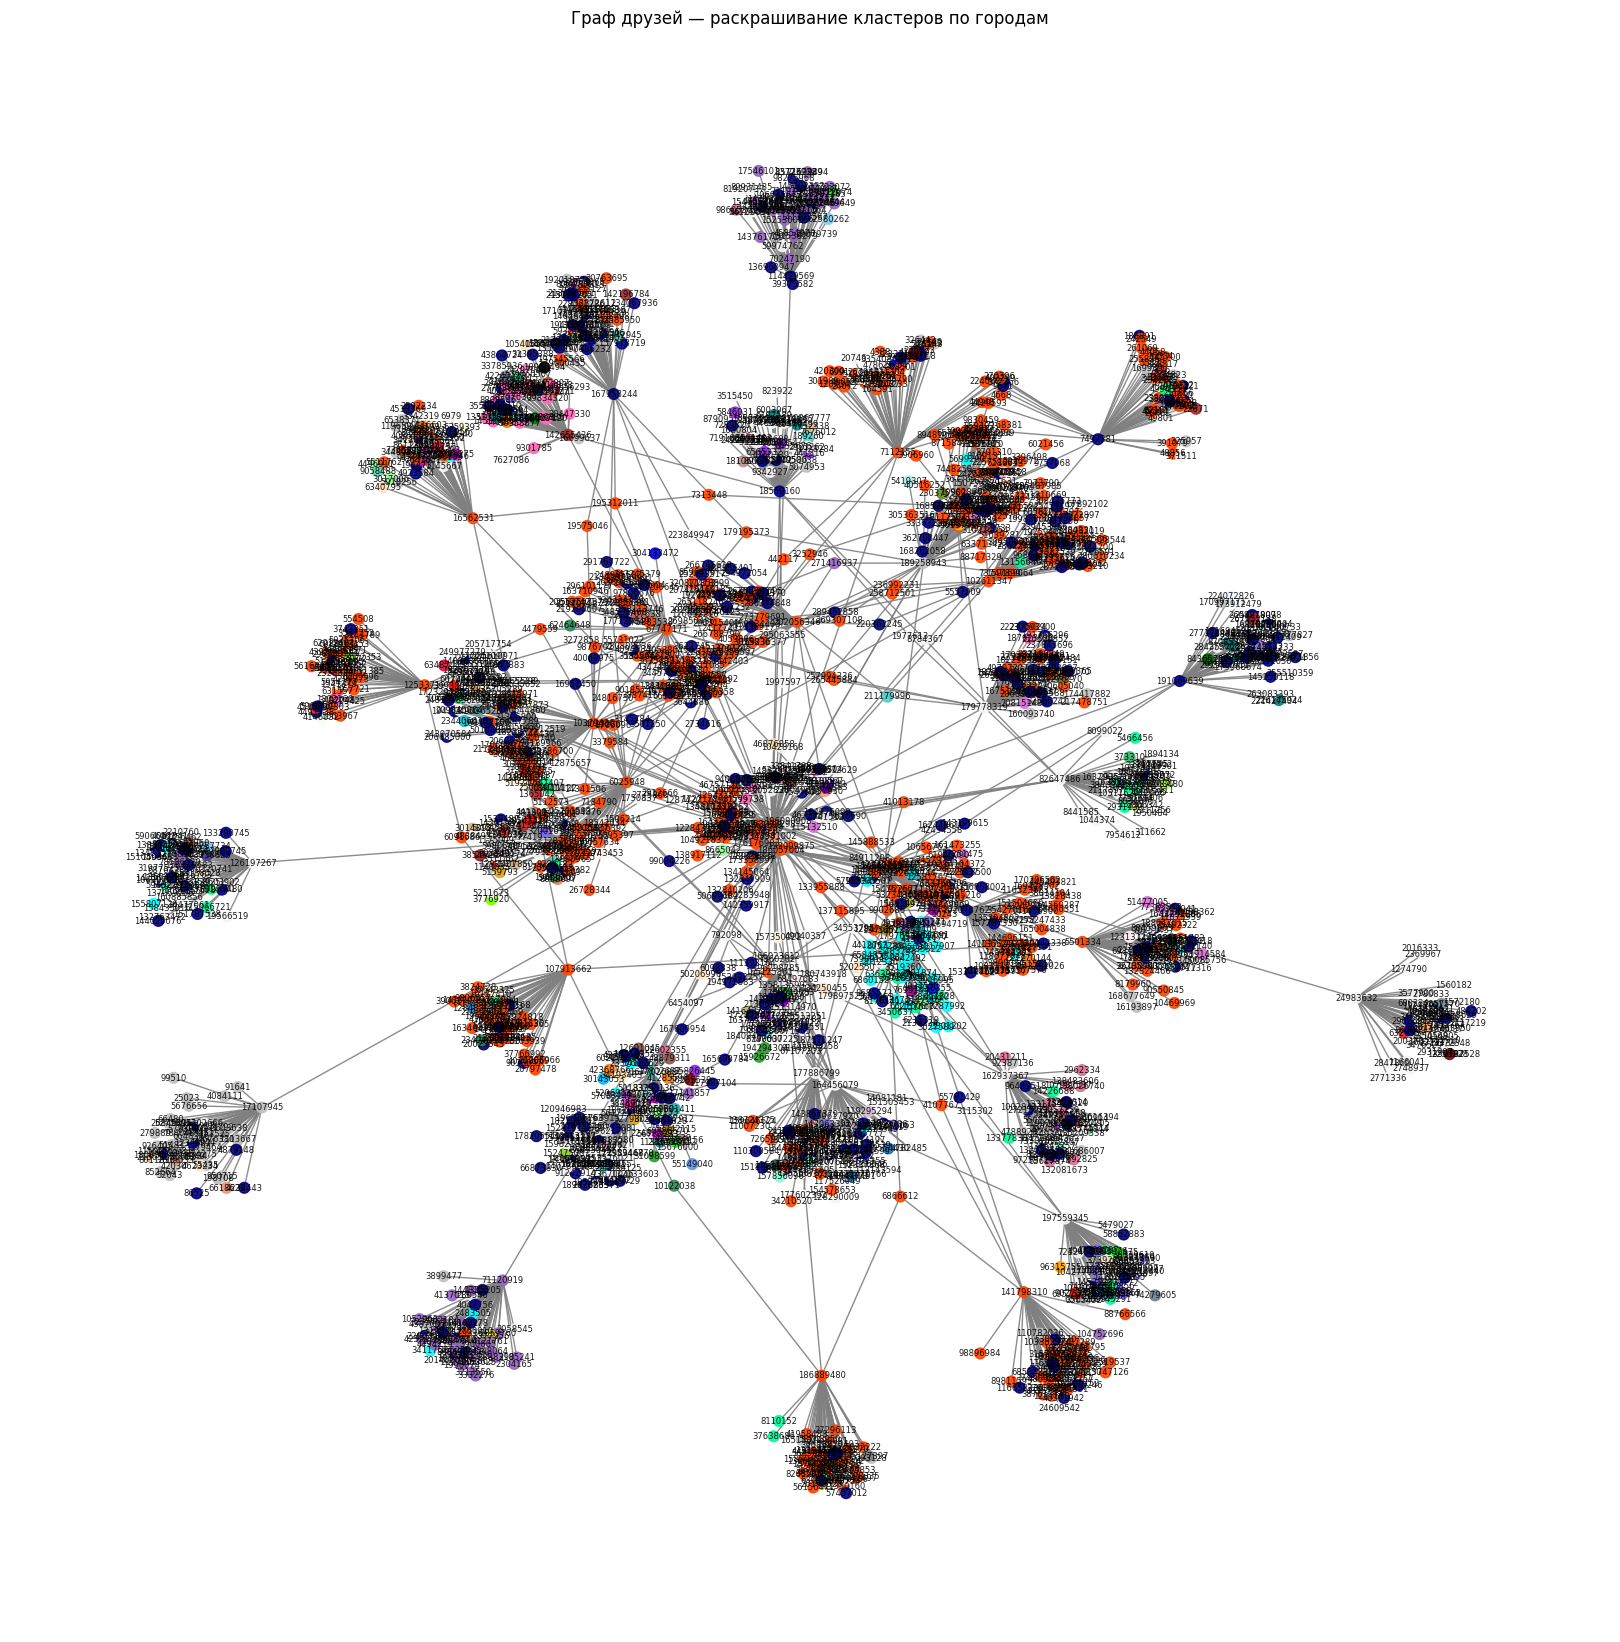

In [94]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# читаем CSV
df = pd.read_csv(f"friends_graph_{central_user_id}.csv")

# строим граф
G = nx.from_pandas_edgelist(df, "from_id", "to_id")

# ---- 1. Собираем города для каждого user_id ----
user_city = {}

# для from_id
for _, row in df.iterrows():
    uid = row["from_id"]
    city = row["from_city"] if pd.notna(row["from_city"]) else "Unknown"
    user_city[uid] = city

    uid2 = row["to_id"]
    city2 = row["to_city"] if pd.notna(row["to_city"]) else "Unknown"
    user_city[uid2] = city2

# список уникальных городов
cities = list(set(user_city.values()))
# print("Найдено городов:", len(cities), cities)

# ---- 2. Генерируем цвета ----
color_palette = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
city_to_color = {city: color_palette[i % len(color_palette)] for i, city in enumerate(cities)}

# ---- 3. Формируем цвета узлов для графа ----
node_colors = [city_to_color[user_city[node]] for node in G.nodes()]

# ---- 4. Рисуем граф ----
plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    with_labels=True,
    font_size=6,
    node_size=60,
    edge_color="gray",
    alpha=0.9
)

plt.title("Граф друзей — раскрашивание кластеров по городам")
plt.show()


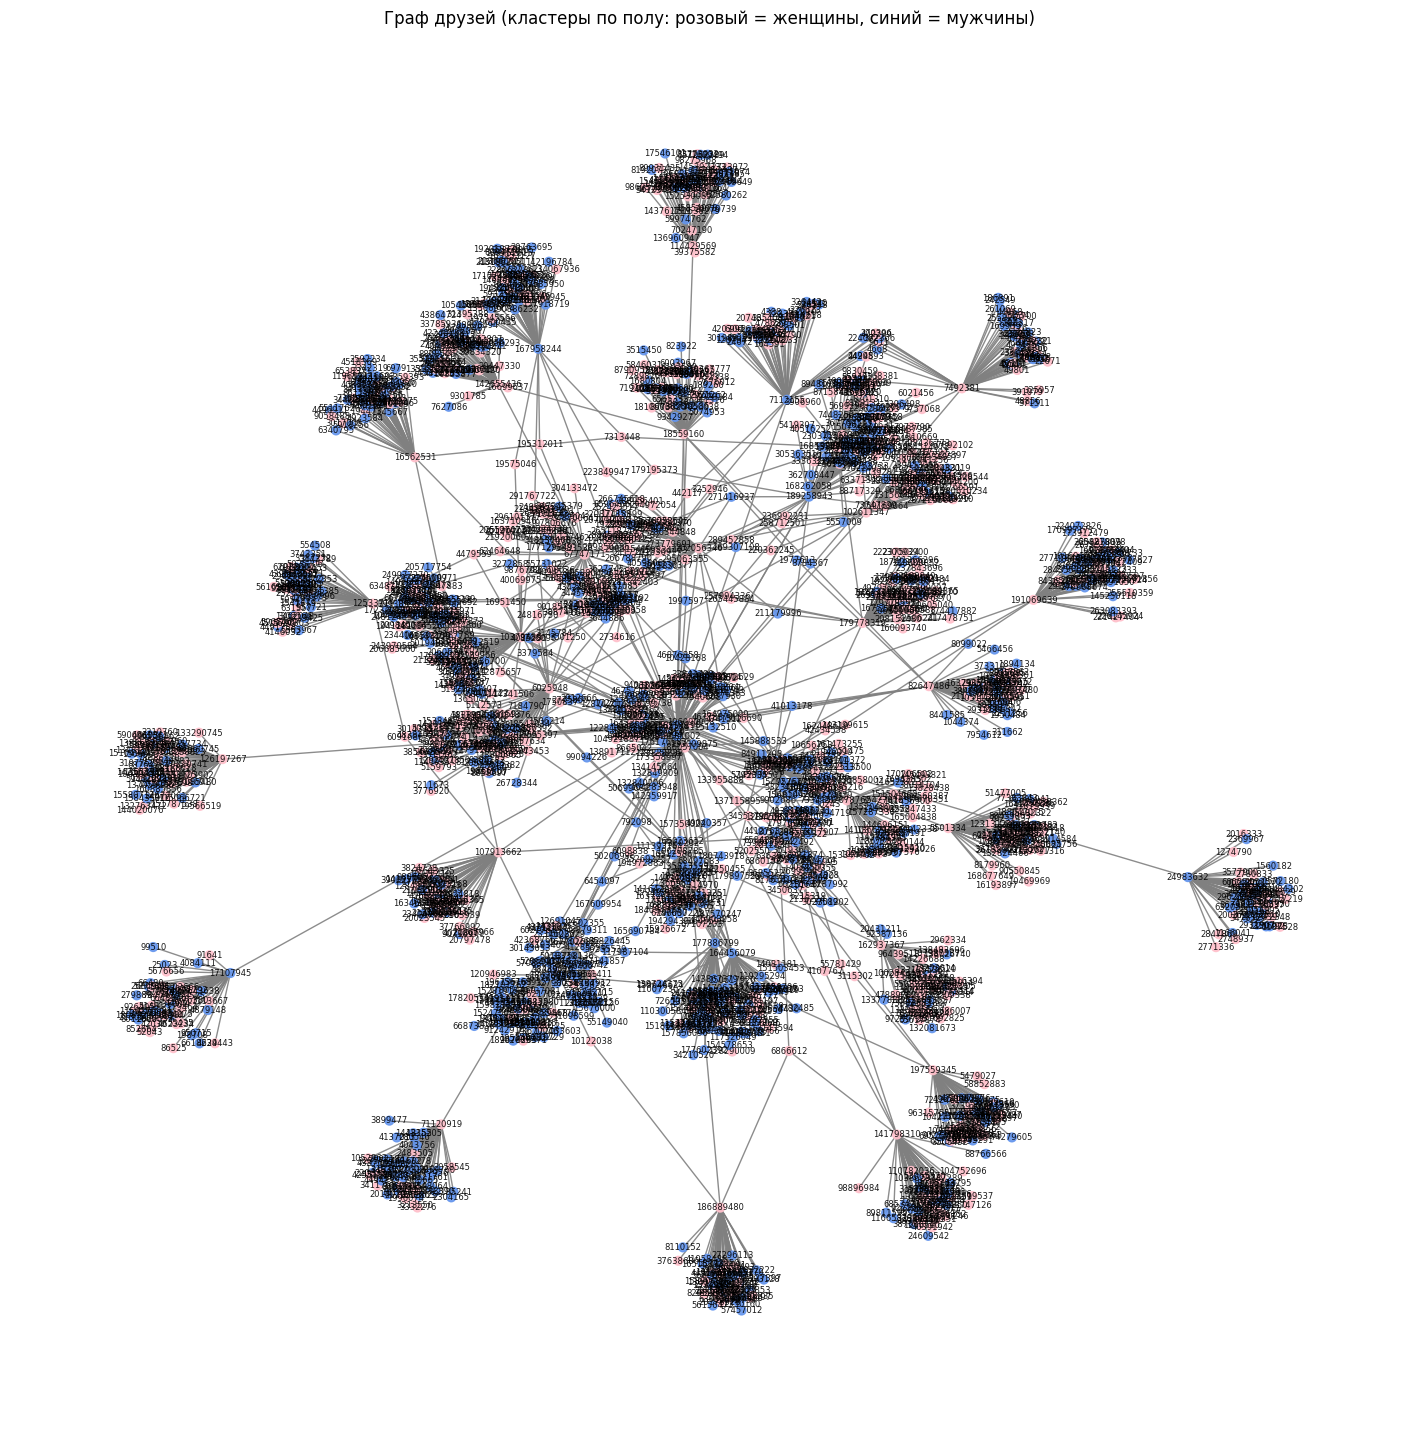

In [95]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Загружаем CSV, который содержит пол и города
df = pd.read_csv(f"friends_graph_{central_user_id}.csv")

# Строим граф
G = nx.from_pandas_edgelist(df, "from_id", "to_id")

# --- Собираем пол пользователя из CSV ----
sex_map = {}

# "from" данные
for _, row in df.iterrows():
    if not pd.isna(row["from_sex"]):
        sex_map[row["from_id"]] = int(row["from_sex"])

# "to" данные
for _, row in df.iterrows():
    if not pd.isna(row["to_sex"]):
        sex_map[row["to_id"]] = int(row["to_sex"])

# ---- Цвета по полу ----
def get_color(node):
    sex = sex_map.get(node, 0)
    if sex == 1:
        return "pink"             # женщины
    elif sex == 2:
        return "cornflowerblue"   # мужчины
    return "gray"                 # неизвестно

node_colors = [get_color(n) for n in G.nodes()]

# ---- Рисуем граф ----
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    with_labels=True,
    font_size=6,
    node_size=40,
    edge_color="gray",
    alpha=0.9,
)

plt.title("Граф друзей (кластеры по полу: розовый = женщины, синий = мужчины)")
plt.show()


# Карта друзей по городам

https://datalens.yandex/q9slp7zhwyrqb

In [63]:
!pip install plotly


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import pandas as pd

# Загружаем CSV
df = pd.read_csv("friends_graph_253997298.csv")

# Берём только строки, где город друга указан
df_valid = df.dropna(subset=["to_city"])   # убрать пустые

# Группировка: сколько раз каждый город встречается среди друзей
city_counts = df_valid.groupby("to_city").size().sort_values(ascending=False)

# Вывод
print("Количество друзей по городам:")
for city, count in city_counts.items():
    print(f"{city}: {count}")


Количество друзей по городам:
Пенза: 617
Москва: 468
Санкт-Петербург: 150
Саратов: 56
Самара: 39
Казань: 25
Киров: 21
Уфа: 16
Воронеж: 14
Чебоксары: 13
Краснодар: 10
Нижний Новгород: 9
Заречный: 8
Красноярск: 8
Пермь: 7
Сочи: 6
Старый Оскол: 5
Тольятти: 5
Новосибирск: 5
Калининград: 5
Пенза (деревня): 5
Ростов-на-Дону: 4
Элиста: 4
Подольск: 4
Тюмень: 4
Омск: 4
Ливны: 4
Петрозаводск: 3
Ижевск: 3
Марс: 3
Кузнецк: 3
Кострома: 3
Белгород: 3
Владивосток: 3
Хабаровск: 3
Тамбов: 3
Ялта: 3
Тула: 3
Челябинск: 3
Ульяновск: 3
Химки: 3
Zürich: 2
Красногорск: 2
Томск: 2
Липецк: 2
Волгоград: 2
Брянск: 2
Балашиха: 2
Berlin: 2
Альметьевск: 2
Chicago: 2
Delft: 2
Новокуйбышевск: 2
Новороссийск: 2
Екатеринбург: 2
Грозный: 2
Мытищи: 2
Набережные Челны: 2
Туапсе: 2
Саранск: 2
Саров: 2
Смоленск: 2
Симферополь: 2
Псков: 2
Анна: 1
Анапа: 1
Батуми: 1
Белая Холуница: 1
Власово: 1
Витебск: 1
Братск: 1
Великие Луки: 1
Богданович: 1
Бабаево: 1
Shanghai: 1
Sittard: 1
Ho Chi Minh City: 1
Birmingham: 1
Chiang Mai: 1


In [79]:
!pip install geopy


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import requests
import time

API_KEY = "01b1b2a6-0d26-4385-bb46-2b903ce032d1"
GEOCODER_URL = "https://geocode-maps.yandex.ru/v1/"

# ==== 1. Читаем исходный CSV с друзьями ====
df = pd.read_csv("friends_graph_253997298.csv")

# Берём только строки, где есть город друга
df_cities = df.dropna(subset=["to_city"])

# Считаем, сколько друзей в каждом городе (заодно получим список уникальных городов)
city_counts = (
    df_cities["to_city"]
    .value_counts()
    .rename_axis("to_city")
    .reset_index(name="friends_count")
)

print("Количество друзей по городам (топ 10):")
print(city_counts.head(10))


# ==== 2. Функция геокодера Яндекса ====
def geocode_city_yandex(city_name: str):
    params = {
        "apikey": API_KEY,
        "geocode": city_name,
        "lang": "ru_RU",
        "kind": "locality",
        "results": 1,
        "format": "json",
    }

    try:
        r = requests.get(GEOCODER_URL, params=params, timeout=5)
        r.raise_for_status()
        data = r.json()

        members = (
            data.get("response", {})
                .get("GeoObjectCollection", {})
                .get("featureMember", [])
        )
        if not members:
            return None, None

        geo_obj = members[0]["GeoObject"]
        pos_str = geo_obj["Point"]["pos"]  # "lon lat"
        lon_str, lat_str = pos_str.split()
        return float(lat_str), float(lon_str)
    except Exception as e:
        print(f"[ГЕОКОДЕР ОШИБКА] {city_name}: {e}")
        return None, None


# ==== 3. Геокодируем УНИКАЛЬНЫЕ города ====
city_to_coords = {}

for city in city_counts["to_city"]:
    lat, lon = geocode_city_yandex(city + ", Россия")
    city_to_coords[city] = (lat, lon)
    print(f"{city} → {lat}, {lon}")
    time.sleep(0.3)   # чтобы не спамить API


# ==== 4. Добавляем координаты в исходный df ====
def get_lat(city):
    coords = city_to_coords.get(city)
    return coords[0] if coords else None

def get_lon(city):
    coords = city_to_coords.get(city)
    return coords[1] if coords else None

df["to_city_lat"] = df["to_city"].map(get_lat)
df["to_city_lon"] = df["to_city"].map(get_lon)

# при желании аналогично можно сделать from_city_lat/from_city_lon,
# если в df есть колонка from_city

# ==== 5. Сохраняем обновлённый CSV ====
out_path = "friends_graph_253997298.csv"
df.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Файл с координатами сохранён: {out_path}")


Количество друзей по городам (топ 10):
           to_city  friends_count
0            Пенза            617
1           Москва            468
2  Санкт-Петербург            150
3          Саратов             56
4           Самара             39
5           Казань             25
6            Киров             21
7              Уфа             16
8          Воронеж             14
9        Чебоксары             13
Пенза → 53.195042, 45.018316
Москва → 55.755864, 37.617698
Санкт-Петербург → 59.938676, 30.314494
Саратов → 51.533338, 46.034176
Самара → 53.195878, 50.100202
Казань → 55.796127, 49.106414
Киров → 58.603595, 49.668023
Уфа → 54.735152, 55.958736
Воронеж → 51.660781, 39.200296
Чебоксары → 56.139918, 47.247728
Краснодар → 45.03547, 38.975313
Нижний Новгород → 56.326797, 44.006516
Заречный → 53.196088, 45.169071
Красноярск → 56.010543, 92.852581
Пермь → 58.010455, 56.229443
Сочи → 43.585472, 39.723098
Пенза (деревня) → 55.791881, 42.082244
Новосибирск → 55.030204, 82.92043
Тольятти → 

In [ ]:
import pandas as pd
from time import sleep

REQUEST_DELAY = 0.35  # как и раньше

def get_random_users_from_city(city_id, total_users=1000, batch_size=200):
    """
    Получить до total_users пользователей из указанного города через users.search.
    Результат возвращает как DataFrame и сохраняет в CSV.
    """
    total_users = min(total_users, 1000)   # VK больше 1000 не даст
    users = []
    offset = 0

    while len(users) < total_users:
        params = {
            "city": city_id,              # ID города (например, 109 для Пензы)
            "count": batch_size,
            "offset": offset,
            "sort": 0,                    # по популярности
            "has_photo": 1,               # только с фото (можно убрать)
            "sex": 0,                     # любой пол
            "fields": "city,sex,bdate"    # доп. поля по желанию
        }

        data = make_vk_request("users.search", params)

        # если запрос вообще не удался
        if not data:
            print("[users.search] пустой ответ от VK")
            break

        # если VK вернул ошибку, поле response может отсутствовать
        if "response" not in data:
            print("[users.search] нет поля 'response' в ответе, полный ответ:")
            print(data)
            break

        items = data["response"].get("items", [])
        if not items:   # больше результатов нет
            break

        users.extend(items)
        offset += batch_size

        if len(items) < batch_size:
            # VK вернул меньше, чем просили — дальше уже нечего листать
            break

        sleep(REQUEST_DELAY)

    # обрежем до нужного количества
    users = users[:total_users]

    df = pd.DataFrame(users)
    csv_name = f"users_city_{city_id}.csv"
    df.to_csv(csv_name, index=False, encoding="utf-8-sig")
    print(f"Итого пользователей: {len(df)}, файл: {csv_name}")

    return df

In [107]:
CITY_ID = 109  # Пенза, возьми любой, который хочешь
df_city_users = get_random_users_from_city(CITY_ID, total_users=1000, batch_size=50)

Итого пользователей: 386, файл: users_city_109.csv


In [ ]:
def print_top_names(df, top_n=10):
    # оставляем только строки, где есть пол и имя
    df = df.dropna(subset=["sex", "first_name"])

    # женщины (sex = 1)
    girls = df[df["sex"] == 1]
    # мужчины (sex = 2)
    boys = df[df["sex"] == 2]

    top_girls = girls["first_name"].value_counts().head(top_n)
    top_boys = boys["first_name"].value_counts().head(top_n)

    print("Топ женских имён:")
    print(top_girls.to_string())

    print("\nТоп мужских имён:")
    print(top_boys.to_string())

print_top_names(df_city_users, top_n=10)


    sex_group to_first_name  count
48          Ж     Анастасия     57
88          Ж         Елена     49
87          Ж     Екатерина     47
164         Ж         Ольга     44
139         Ж         Мария     43
197         Ж          Юлия     43
55          Ж          Анна     41
183         Ж       Татьяна     35
153         Ж       Наталья     30
100         Ж         Ирина     25
242         М     Александр     79
374         М        Сергей     56
244         М       Алексей     48
252         М        Андрей     46
304         М       Дмитрий     45
337         М        Максим     35
345         М        Михаил     33
349         М        Никита     28
301         М         Денис     27
319         М          Илья     27


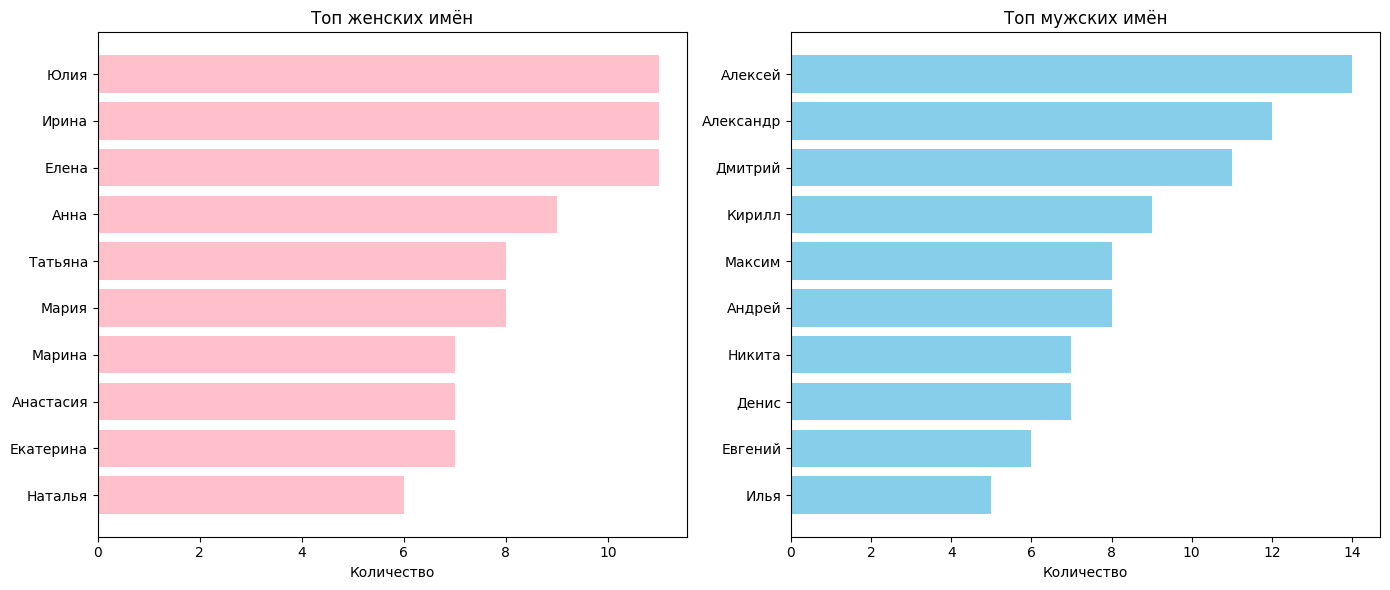

In [123]:
import matplotlib.pyplot as plt

def plot_top_names(df, top_n=10):
    # убираем строки без пола или имени
    df = df.dropna(subset=["sex", "first_name"])

    # женщины = sex 1
    girls = df[df["sex"] == 1]["first_name"].value_counts().head(top_n)

    # мужчины = sex 2
    boys  = df[df["sex"] == 2]["first_name"].value_counts().head(top_n)

    # --- РИСУЕМ ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Левый график — женщины
    axes[0].barh(girls.index, girls.values, color="pink")
    axes[0].set_title("Топ женских имён")
    axes[0].invert_yaxis()   # чтобы самое популярное было сверху
    axes[0].set_xlabel("Количество")

    # Правый график — мужчины
    axes[1].barh(boys.index, boys.values, color="skyblue")
    axes[1].set_title("Топ мужских имён")
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Количество")

    plt.tight_layout()
    plt.show()


# ВЫЗОВ ФУНКЦИИ
plot_top_names(df_city_users, top_n=10)


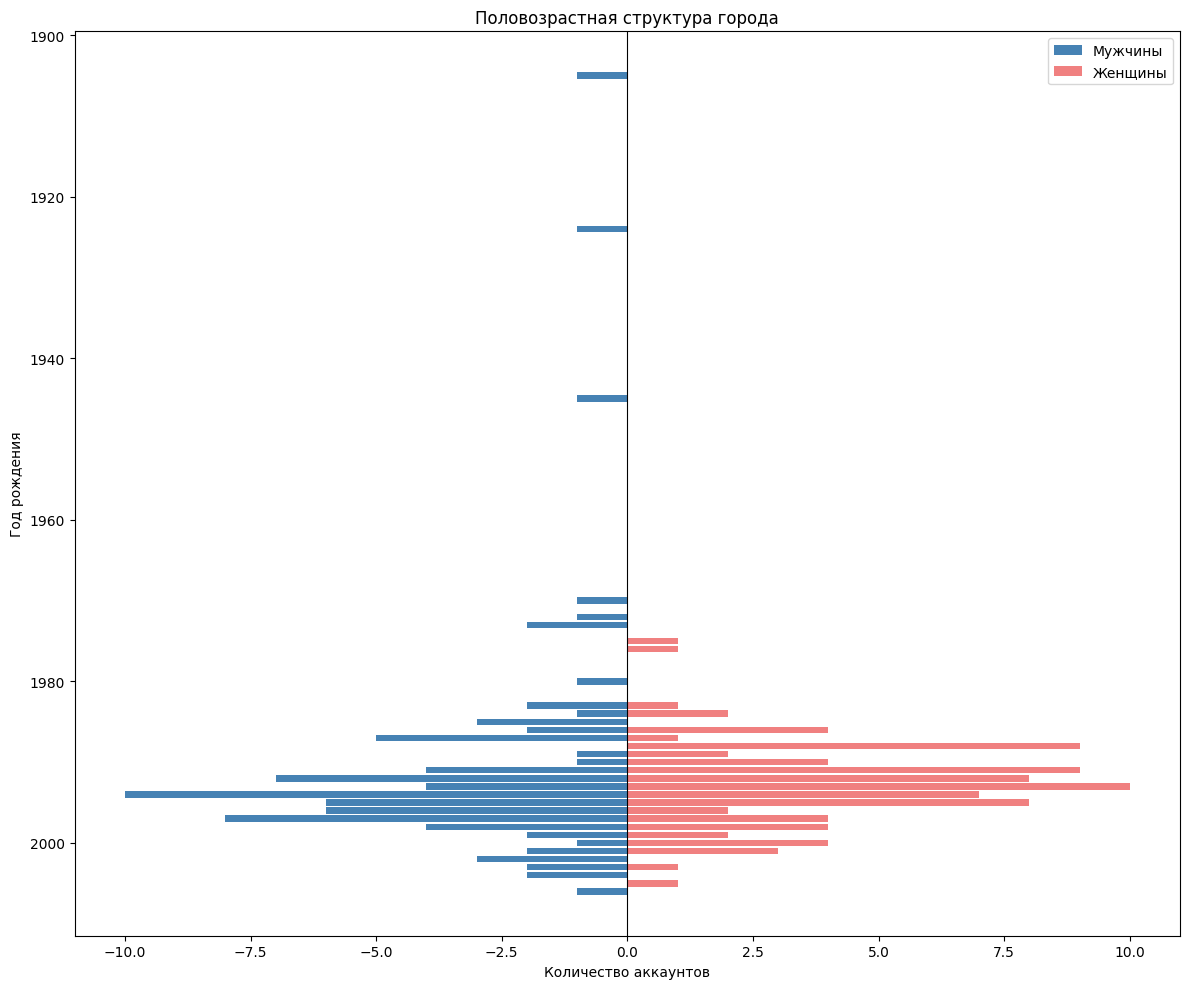

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. Берём уже загруженный df_city_users ===
df = df_city_users.copy()

# === 2. Выделяем год рождения ===
def extract_year(bdate):
    if isinstance(bdate, str) and len(bdate.split('.')) == 3:
        return int(bdate.split('.')[-1])
    return None

df["birth_year"] = df["bdate"].apply(extract_year)

# Удаляем строки без года рождения
df = df.dropna(subset=["birth_year"])

# === 3. Разделяем по полу ===
males = df[df["sex"] == 2]   # мужчины
females = df[df["sex"] == 1] # женщины

# === 4. Считаем распределение по годам ===
male_counts = males["birth_year"].value_counts().sort_index()
female_counts = females["birth_year"].value_counts().sort_index()

# === 5. Готовим данные для пирамиды ===
years = sorted(set(male_counts.index) | set(female_counts.index))

male_values = [-male_counts.get(year, 0) for year in years]  # отрицательные для левой части
female_values = [female_counts.get(year, 0) for year in years]

# === 6. Строим график ===
plt.figure(figsize=(12, 10))

plt.barh(years, male_values, color="steelblue", label="Мужчины")
plt.barh(years, female_values, color="lightcoral", label="Женщины")

# Линия по центру
plt.axvline(0, color="black", linewidth=0.8)

# Подписи
plt.title("Половозрастная структура города")
plt.xlabel("Количество аккаунтов")
plt.ylabel("Год рождения")
plt.legend()

# Убираем лишние отступы
plt.tight_layout()
plt.gca().invert_yaxis()  # годы от новых к старым, как в демографических пирамидах

plt.show()
